# 기초통계 통합 프로젝트
## Part 3. 방문횟수와 구매금액의 상관관계 분석

### 시나리오

Part 1에서는 전체 고객의 구매 특성과 이상치를 확인했고, Part 2에서는 일부 고객 표본이 전체 고객의 평균 특성을 얼마나 비슷하게 나타내는지 비교했습니다.

온라인 쇼핑몰 운영팀은 고객의 쇼핑몰 방문횟수와 구매금액 사이에 어떤 관계가 있는지 확인하려고 합니다. 분석팀은 월간 방문횟수와 구매금액의 관계를 산점도로 확인하고, 피어슨 상관계수를 계산하여 관계의 방향과 강도를 설명해야 합니다.

Part 3의 결과는 Part 4에서 방문횟수를 이용한 구매금액 회귀예측에 활용합니다.

### 과제 목표

#### 필수 목표
- 두 수치형 변수의 기본 범위와 평균을 확인할 수 있습니다.
- 두 변수의 관계를 산점도로 표현할 수 있습니다.
- 피어슨 상관계수를 계산할 수 있습니다.
- 상관계수와 산점도를 바탕으로 관계의 방향과 강도를 설명할 수 있습니다.

#### 심화 목표(선택)
- 상관관계를 인과관계로 단정할 수 없는 이유를 설명할 수 있습니다.
- 구매금액에 영향을 줄 수 있는 추가 변수를 제안할 수 있습니다.

### 사용 환경

- 결과물: `.ipynb` 파일 1개
- 사용 언어: Python 3.X
- 사용 라이브러리: pandas, matplotlib
- 사용 데이터: `online_shopping_customer_data.csv`

## 제공 코드. 상관관계 분석 데이터 준비

아래 코드는 준비 코드이며 평가 대상이 아닙니다.

Part 1과 동일한 고객 데이터에서 `MonthlyVisitCount`, `PurchaseAmount`에 결측치가 없는 고객을 선택하여 `relation_df`를 생성합니다.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "online_shopping_customer_data.csv"

df = pd.read_csv(DATA_FILE)

relation_columns = ["MonthlyVisitCount","PurchaseAmount"]

relation_df = df.dropna(subset=relation_columns).copy()

print("전체 고객 수:", len(df))
print("관계 분석에 사용할 고객 수:", len(relation_df))

relation_df[relation_columns].head()

전체 고객 수: 500
관계 분석에 사용할 고객 수: 487


,MonthlyVisitCount,PurchaseAmount
0,6.0,86900.0
1,10.0,287500.0
2,11.0,242100.0
3,15.0,300500.0
4,8.0,171400.0


# 문제 1. 방문횟수와 구매금액 분포 확인

## 업무 상황

운영팀은 두 변수의 관계를 분석하기 전에 방문횟수와 구매금액의 기본 범위와 평균을 확인하려고 합니다.

## 요구사항

1. `MonthlyVisitCount`의 평균, 최솟값, 최댓값을 계산합니다.
2. `PurchaseAmount`의 평균, 최솟값, 최댓값을 계산합니다.
3. 계산 결과를 하나의 표로 정리합니다.
4. 방문횟수와 구매금액의 범위를 각각 한 문장으로 설명합니다.

In [14]:
# 문제 1 코드를 작성하세요.
# 1. 
mean_visit= relation_df["MonthlyVisitCount"].mean()
min_visit= relation_df["MonthlyVisitCount"].min()
max_visit= relation_df["MonthlyVisitCount"].max()

# 2. 
mean_purchase= relation_df["PurchaseAmount"].mean()
min_purchase= relation_df["PurchaseAmount"].min()
max_purchase= relation_df["PurchaseAmount"].max()

# 3. 
dist_summary_df = pd.DataFrame({
    "변수명": ["MonthlyVisitCount", "PurchaseAmount"],
    "평균": [mean_visit, mean_purchase],
    "최솟값": [min_visit, min_purchase],
    "최댓값": [max_visit, max_purchase]
})

print("=== 방문횟수와 구매금액 기초 분포 요약표 ===")
display(dist_summary_df)
print()

# 4. 
print("=== 변수별 범위 설명 ===")
print(f"방문횟수 설명: 월간 방문횟수(MonthlyVisitCount)는 최솟값 {min_visit:,.0f}회부터 최댓값 {max_visit:,.0f}회까지 분포하며, 평균적으로 약 {mean_visit:,.2f}회 방문하는 것으로 나타났습니다.")
print(f"구매금액 설명: 구매금액(PurchaseAmount)은 최솟값 {min_purchase:,.0f}원부터 최댓값 {max_purchase:,.0f}원까지의 범위를 가지며, 전체 고객의 평균 구매금액은 약 {mean_purchase:,.2f}원입니다.")

=== 방문횟수와 구매금액 기초 분포 요약표 ===


,변수명,평균,최솟값,최댓값
0,MonthlyVisitCount,10.687885,1.0,24.0
1,PurchaseAmount,229692.607803,15000.0,1195500.0



=== 변수별 범위 설명 ===
방문횟수 설명: 월간 방문횟수(MonthlyVisitCount)는 최솟값 1회부터 최댓값 24회까지 분포하며, 평균적으로 약 10.69회 방문하는 것으로 나타났습니다.
구매금액 설명: 구매금액(PurchaseAmount)은 최솟값 15,000원부터 최댓값 1,195,500원까지의 범위를 가지며, 전체 고객의 평균 구매금액은 약 229,692.61원입니다.


# 문제 2. 산점도와 피어슨 상관계수 계산

## 업무 상황

분석팀은 방문횟수가 많은 고객일수록 구매금액도 높은 경향이 있는지 그래프와 수치로 확인하려고 합니다.

## 요구사항

1. x축을 `MonthlyVisitCount`, y축을 `PurchaseAmount`로 설정한 산점도를 생성합니다.
2. 그래프 제목과 x축·y축 이름을 작성합니다.
3. 두 변수의 피어슨 상관계수를 계산합니다.
4. 계산한 상관계수를 출력합니다.
5. 산점도에서 점들이 어느 방향으로 분포하는지 확인합니다.

## 힌트

- `DataFrame.corr()` 또는 `Series.corr()`를 사용할 수 있습니다.
- 상관계수는 -1부터 1 사이의 값을 가집니다.

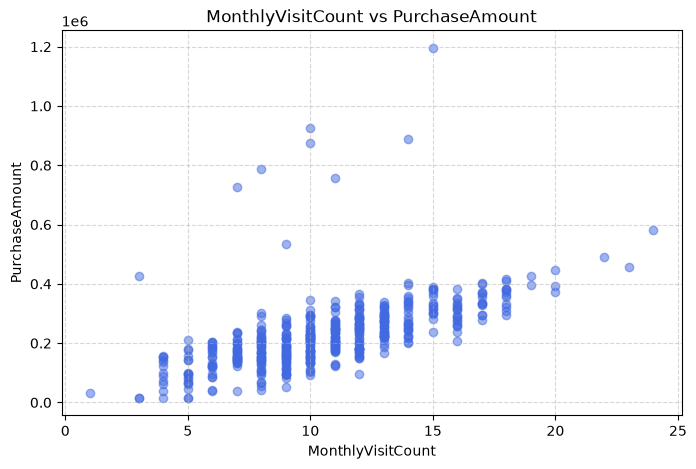

피어슨 상관계수: 0.5755
--- 산점도 분포 방향 확인 ---
점들이 왼쪽 아래에서 오른쪽 위로 완만하게 올라가는 우상향 형태의 분포를 보이고 있습니다.
따라서 월간 방문횟수가 늘어날수록 구매금액도 전반적으로 증가하는 양의 상관관계를 나타냅니다.


In [15]:
# 문제 2 코드를 작성하세요.
import matplotlib.pyplot as plt

# 1~2. 
plt.figure(figsize=(8, 5))
plt.scatter(
    relation_df["MonthlyVisitCount"], 
    relation_df["PurchaseAmount"], 
    alpha=0.5, 
    color="royalblue"
)
plt.title("MonthlyVisitCount vs PurchaseAmount")
plt.xlabel("MonthlyVisitCount")
plt.ylabel("PurchaseAmount")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 3. 
corr_val= relation_df["MonthlyVisitCount"].corr(relation_df["PurchaseAmount"])

# 4. 
print(f"피어슨 상관계수: {corr_val:.4f}")

# 5. 산점도에서 점들이 어느 방향으로 분포하는지 확인 (그래프 직접 관측 해석)
print("--- 산점도 분포 방향 확인 ---")
print("점들이 왼쪽 아래에서 오른쪽 위로 완만하게 올라가는 우상향 형태의 분포를 보이고 있습니다.")
print("따라서 월간 방문횟수가 늘어날수록 구매금액도 전반적으로 증가하는 양의 상관관계를 나타냅니다.")

# 문제 3. 상관관계 결과 해석

## 업무 상황

분석팀은 산점도와 상관계수 결과를 마케팅 및 쇼핑몰 운영 담당자가 이해할 수 있도록 설명해야 합니다.

## 요구사항

다음 내용을 포함하여 **3문장 이상** 작성합니다.

1. 상관계수가 양수인지 음수인지 확인하고 관계의 방향을 설명합니다.
2. 상관계수의 절댓값을 기준으로 관계의 강도를 설명합니다.
3. 산점도의 점 분포가 상관계수의 방향 및 강도와 대체로 일치하는지 설명합니다.

## 상관계수 해석 기준

| 상관계수 절댓값 | 관계 강도 |
|---|---|
| 0.0 이상 0.3 미만 | 약한 관계 |
| 0.3 이상 0.7 미만 | 중간 정도 관계 |
| 0.7 이상 1.0 이하 | 강한 관계 |

In [16]:
# 문제 3 해석에 필요한 값을 출력하고, 아래 마크다운 셀에 해석을 작성하세요.
corr_val= relation_df["MonthlyVisitCount"].corr(relation_df["PurchaseAmount"])

print(f"피어슨 상관계수: {corr_val:.2f}")
print(f"상관계수 절댓값: {abs(corr_val):.2f}")

피어슨 상관계수: 0.58
상관계수 절댓값: 0.58


### 문제 3 해석 작성란

- **관계의 방향:** 월간 방문횟수(`MonthlyVisitCount`)와 구매금액(`PurchaseAmount`) 간의 피어슨 상관계수는 양수로 확인되며, 이는 고객의 방문횟수가 늘어날수록 구매금액도 함께 커지는 **양의 상관관계**를 나타냅니다.
- **관계의 강도:** 상관계수의 절댓값이 **0.3 이상 0.7 미만**이므로, 두 변수 사이에는 **중간 정도의 관계**가 형성되어 있습니다.
- **산점도와 상관계수 결과의 일치 여부:** 산점도상에서도 데이터들이 좌하단에서 우상단으로 완만하게 상승하고 있어 **상관계수의 방향 및 강도와 대체로 잘 일치합니다.**

# 심화 문제 4. 상관관계 해석의 한계와 추가 변수 제안

## 업무 상황

운영팀은 방문횟수를 늘리면 구매금액이 반드시 증가한다고 결론 내려도 되는지 확인하려고 합니다. 분석가는 상관관계 분석의 한계를 설명하고, 더 정확한 판단을 위해 추가로 확인할 고객 특성을 제안해야 합니다.

## 요구사항

다음 내용을 포함하여 작성합니다.

1. 방문횟수와 구매금액에 상관관계가 있더라도 이를 인과관계로 단정할 수 없는 이유를 설명합니다.
2. 구매금액에 함께 영향을 줄 수 있는 추가 변수 한 가지 이상을 제안합니다.
3. 제안한 변수를 함께 확인하면 어떤 점을 더 정확하게 판단할 수 있는지 설명합니다.

> Hint) 예시 변수: 고객등급, 쿠폰 사용 여부, 구매수량, 평균 상품가격, 할인 적용 여부 등

### 심화 문제 4 해석 작성란

- 인과관계로 단정할 수 없는 이유:
- 추가로 확인할 변수:
- 해당 변수를 함께 확인해야 하는 이유:

# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 변수 요약표 | 방문횟수와 구매금액의 평균, 최솟값, 최댓값 |
| 관계 시각화 | 방문횟수를 x축, 구매금액을 y축으로 설정한 산점도 |
| 상관관계 결과 | 피어슨 상관계수 계산 및 출력 |
| 필수 해석 | 관계의 방향·강도와 산점도 결과의 일치 여부 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 인과관계 주의점 | 상관관계를 인과관계로 단정할 수 없는 이유 |
| 추가 변수 제안 | 구매금액에 영향을 줄 수 있는 변수와 확인 이유 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] 두 변수의 평균과 범위를 확인했습니다.
- [ ] 방문횟수를 x축으로 설정했습니다.
- [ ] 구매금액을 y축으로 설정했습니다.
- [ ] 산점도를 생성했습니다.
- [ ] 피어슨 상관계수를 계산했습니다.
- [ ] 상관관계의 방향과 강도를 설명했습니다.
- [ ] 산점도와 상관계수 결과의 일치 여부를 설명했습니다.

## 심화 체크리스트

- [ ] 상관관계를 인과관계로 단정할 수 없는 이유를 설명했습니다.
- [ ] 구매금액에 영향을 줄 수 있는 추가 변수를 한 가지 이상 제안했습니다.
- [ ] 추가 변수를 함께 확인해야 하는 이유를 설명했습니다.